<a href="https://colab.research.google.com/github/RAZAMZALAG/Statistics-2/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir='rtl'>

#df

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
df = pd.read_excel('/content/satisfaction.xlsx')

In [ ]:
df

,id,satisfaction_v2,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,11112,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,110278,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,103199,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,47462,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,120011,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,...,4,2,2,0,2,4,2,5,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,119211,satisfied,Female,disloyal Customer,29,Personal Travel,Eco,1731,5,5,...,2,2,3,3,4,4,4,2,0,0.0
129876,97768,neutral or dissatisfied,Male,disloyal Customer,63,Personal Travel,Business,2087,2,3,...,1,3,2,3,3,1,2,1,174,172.0
129877,125368,neutral or dissatisfied,Male,disloyal Customer,69,Personal Travel,Eco,2320,3,0,...,2,4,4,3,4,2,3,2,155,163.0
129878,251,neutral or dissatisfied,Male,disloyal Customer,66,Personal Travel,Eco,2450,3,2,...,2,3,3,2,3,2,1,2,193,205.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 129880 non-null  int64  
 1   satisfaction_v2                    129880 non-null  object 
 2   Gender                             129880 non-null  object 
 3   Customer Type                      129880 non-null  object 
 4   Age                                129880 non-null  int64  
 5   Type of Travel                     129880 non-null  object 
 6   Class                              129880 non-null  object 
 7   Flight Distance                    129880 non-null  int64  
 8   Seat comfort                       129880 non-null  int64  
 9   Departure/Arrival time convenient  129880 non-null  int64  
 10  Food and drink                     129880 non-null  int64  
 11  Gate location                      1298

In [ ]:
len(df)

129880

<div dir='rtl'>

#הפיכת משתנים קטגוריאליים למספריים

In [ ]:
categorial_cols = df.select_dtypes(include=['object']).columns.tolist()
categorial_cols_values = [list(set(df[c].values)) for c in categorial_cols]
dict(map(lambda i,j : (i,j) , categorial_cols,categorial_cols_values))

{'satisfaction_v2': ['satisfied', 'neutral or dissatisfied'],
 'Gender': ['Female', 'Male'],
 'Customer Type': ['Loyal Customer', 'disloyal Customer'],
 'Type of Travel': ['Personal Travel', 'Business travel'],
 'Class': ['Eco Plus', 'Eco', 'Business']}

In [ ]:
print(df.select_dtypes(exclude=['number']).nunique())

satisfaction_v2    2
Gender             2
Customer Type      2
Type of Travel     2
Class              3
dtype: int64


In [ ]:
df['satisfaction_v2'] = df['satisfaction_v2'].map({'neutral or dissatisfied': 0, 'satisfied': 1})
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df['Customer Type'] = df['Customer Type'].map({'disloyal Customer': 0, 'Loyal Customer': 1})
df['Type of Travel'] = df['Type of Travel'].map({'Personal Travel': 0, 'Business travel': 1})

# 2. מיפוי משתנה אורדינלי (עם סדר פנימי - מהנמוך לגבוה)
class_mapping = {'Eco': 0, 'Eco Plus': 1, 'Business': 2}
df['Class'] = df['Class'].map(class_mapping)



<div dir='rtl'>

#ערכים חסרים

In [ ]:
df.isna().sum()

,0
id,0
satisfaction_v2,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Seat comfort,0
Departure/Arrival time convenient,0


In [ ]:
nulls = df.isna().sum().tolist()

columns_nulls = dict(zip(df.columns, nulls))
sorted_columns_nulls = dict(sorted(columns_nulls.items(), key=lambda x:x[1], reverse=True))
columns_withnull = {k: v for k, v in sorted_columns_nulls.items() if v > 0}
columns_withnull

{'Arrival Delay in Minutes': 393}

<div dir='rtl'>

#drop columns

In [ ]:
df2 = df[['Leg room service', 'Inflight entertainment', 'Seat comfort',\
   'Food and drink', 'Cleanliness', 'Inflight wifi service',\
   'On-board service', 'Checkin service', 'Gate location',\
   'Baggage handling', 'Ease of Online booking', 'Online support', 'Online boarding']].replace(0, np.nan)

df['Inflight_Score'] = df2[['Leg room service', 'Inflight entertainment', 'Seat comfort',\
   'Food and drink', 'Cleanliness', 'Inflight wifi service',\
   'On-board service']].mean(axis = 1)

df['Online_Score'] = df2[['Online boarding', 'Ease of Online booking', 'Online support']].mean(axis = 1)

df['Ground_Score'] = df2[['Checkin service', 'Gate location','Baggage handling']].mean(axis = 1)

Text(0, 0.5, 'Count')

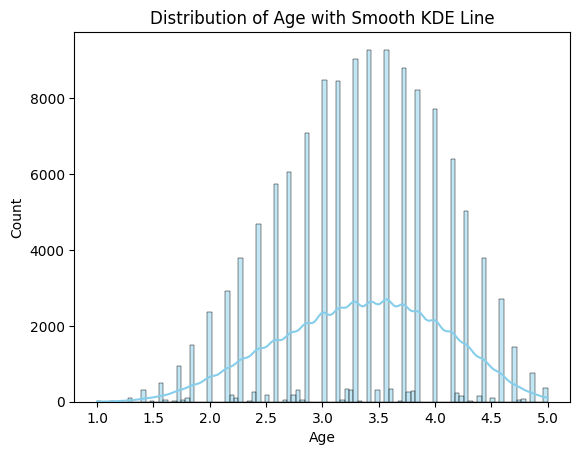

In [ ]:
sns.histplot(df['Inflight_Score'], kde=True, color='skyblue')

plt.title('Distribution of Age with Smooth KDE Line')
plt.xlabel('Age')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

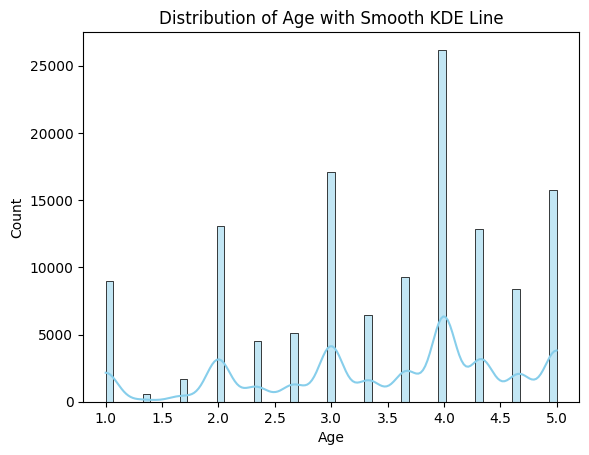

In [ ]:
sns.histplot(df['Online_Score'], kde=True, color='skyblue')

plt.title('Distribution of Age with Smooth KDE Line')
plt.xlabel('Age')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

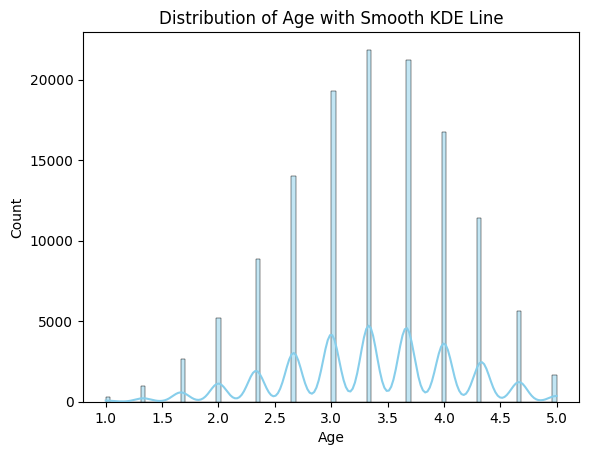

In [ ]:
sns.histplot(df['Ground_Score'], kde=True, color='skyblue')

plt.title('Distribution of Age with Smooth KDE Line')
plt.xlabel('Age')
plt.ylabel('Count')

In [ ]:
df = df.drop(columns = ['id', 'Arrival Delay in Minutes'])

In [ ]:
df = df.drop(columns = ['Leg room service', 'Inflight entertainment', 'Seat comfort',\
   'Food and drink', 'Cleanliness', 'Inflight wifi service',\
   'On-board service', 'Checkin service', 'Gate location',\
   'Baggage handling', 'Ease of Online booking', 'Online support', 'Online boarding'])

In [ ]:
df

,satisfaction_v2,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Departure/Arrival time convenient,Departure Delay in Minutes,Inflight_Score,Online_Score,Ground_Score
0,1,1,1,65,0,0,265,0,0,3.000000,2.333333,3.333333
1,1,0,1,47,0,2,2464,0,310,3.250000,2.333333,3.000000
2,1,1,1,15,0,0,2138,0,0,3.000000,2.000000,3.666667
3,1,1,1,60,0,0,623,0,0,2.250000,2.333333,2.666667
4,1,1,1,70,0,0,354,0,0,2.750000,3.666667,3.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
129875,1,1,0,29,0,0,1731,5,0,3.857143,2.000000,3.666667
129876,0,0,0,63,0,2,2087,3,174,2.000000,1.666667,2.666667
129877,0,0,0,69,0,0,2320,0,155,3.000000,2.666667,3.000000
129878,0,0,0,66,0,0,2450,2,193,2.428571,2.333333,2.333333


In [ ]:
df['Customer Type'].value_counts()

,count
Customer Type,
1,106100
0,23780


<div dir='rtl'>

#drop rows

In [ ]:
df_sampled = df.sample(n=10000, random_state=42)

df_sampled.to_csv('satisfaction_reduced.csv', index=False)

In [ ]:
df = pd.read_csv('satisfaction_reduced.csv')

<div dir='rtl'>

#graphs

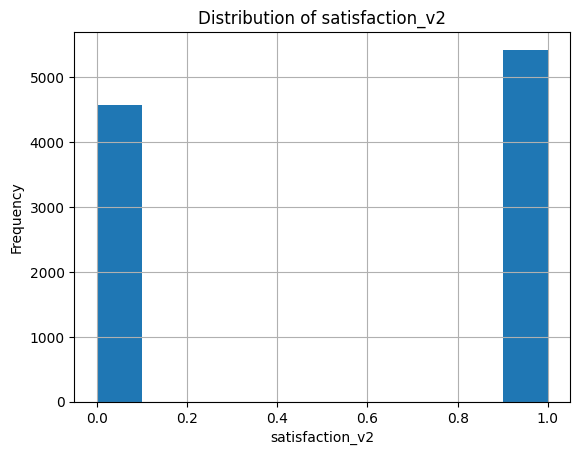

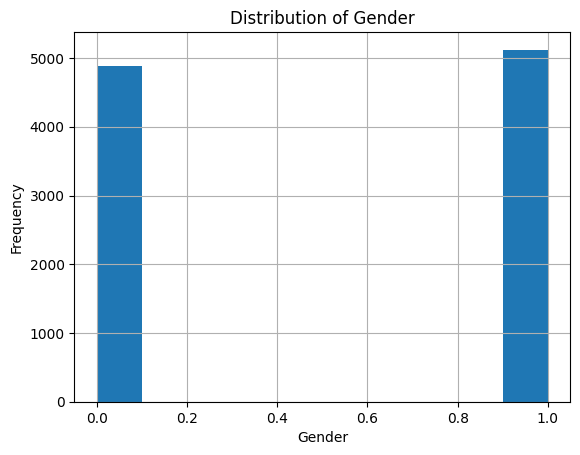

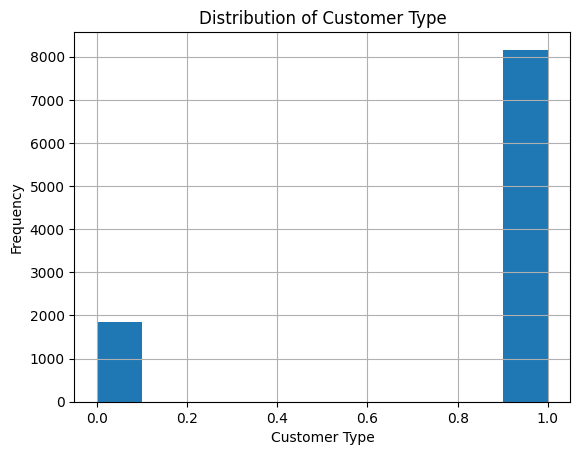

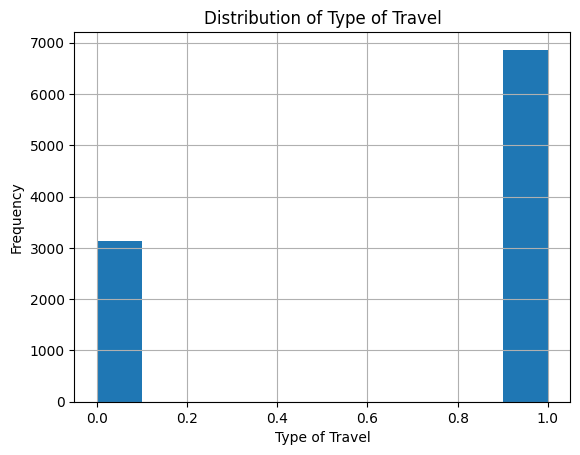

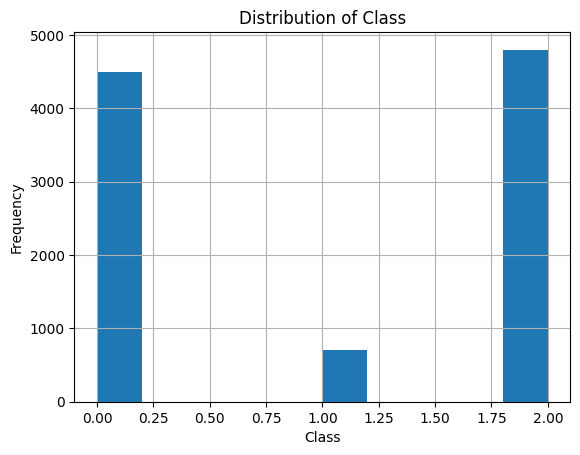

In [ ]:
for col in categorial_cols:
  df[col].hist()
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.title('Distribution of {}'.format(col))
  plt.show()

In [ ]:
df

,satisfaction_v2,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Departure/Arrival time convenient,Departure Delay in Minutes,Inflight_Score,Online_Score,Ground_Score
0,1,1,1,59,1,2,1470,4,7,4.142857,3.666667,4.333333
1,0,1,0,22,1,0,1771,1,0,2.571429,4.333333,2.666667
2,1,0,1,55,1,2,3657,5,12,4.200000,3.666667,3.000000
3,1,1,1,41,1,2,1796,4,0,3.000000,3.666667,3.000000
4,0,0,1,42,1,0,1709,3,0,2.857143,2.000000,2.666667
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,1,43,1,2,2680,1,0,3.428571,2.666667,3.000000
9996,1,0,1,58,1,2,1721,1,0,2.857143,4.333333,3.333333
9997,0,0,1,30,1,2,3646,2,1,3.142857,4.000000,1.666667
9998,1,0,1,50,1,2,1872,1,1,3.571429,4.333333,3.666667
